## Edge Cases: Efficiency vs. Accuracy

### 1. Trade-offs between Computational Cost and Classification Performance


Edge machine learning is a heavily discussed topic. Air quality monitoring is often done
on edge devices (small, low-power sensors in the city), and running a massive stacking
ensemble might be too heavy for a battery-powered or low power chip. We aim to find
the frontier between model size and performance.

* Heavy Model: A 3-layer Stacking Classifier (XGBoost + RF + SVM).
* Light Model: A highly pruned Decision Tree or a LightGBM with limited depth.
* Measurement: Measure not just Accuracy/F1-Score, but also Inference Time (ms)
and Model Size (MB).

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score

import optuna
from optuna.samplers import TPESampler

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [35]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")

target_col = data.columns[-1]

quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)
data[target_col] = data[target_col].astype("int8")

In [36]:
X, y = data.drop(columns=data.columns[-1]), data[data.columns[-1]]

In [37]:

# Splitting the data into 80% training and 20% testing
# Stratify to maintain class distribution in both sets 
# as we are dealing with class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Optuna

In [38]:
def objective_dt(trial: optuna.Trial):

    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        # Cost-complexity pruning should keep the tree small
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.05),
        "random_state": 42,
    }

    model = DecisionTreeClassifier(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=CV, scoring="f1_macro", n_jobs=-1
    )
    return scores.mean()

In [39]:
study_dt = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="decision_tree_tuning",
)

study_dt.optimize(objective_dt, n_trials=100, show_progress_bar=True)

print(f"\nBest macro F1 Score: {study_dt.best_value:.4f}")
print(f"Best params: {study_dt.best_params}")

Best trial: 97. Best value: 0.895099: 100%|██████████| 100/100 [00:08<00:00, 12.43it/s]


Best macro F1 Score: 0.8951
Best params: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.00023458773699438647}


In [ ]:
#Training the decision tree on best params
best_dt = DecisionTreeClassifier(**study_dt.best_params, random_state=42)
best_dt.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)
accuracy_dt  = accuracy_score(y_test, y_pred_dt)
f1_w_dt      = f1_score(y_test, y_pred_dt, average='weighted')
f1_m_dt      = f1_score(y_test, y_pred_dt, average='macro')

print(f"Optimised Decision Tree Scores \nAccuracy: {accuracy_dt:.4f}\nF1-weighted: {f1_w_dt:.4f}\nF1-macro: {f1_m_dt:.4f}")

Optimised Decision Tree Scores 
Accuracy: 0.9180
F1-weighted: 0.9170
F1-macro: 0.8778


## Heavy Model

### Base estimators optimisation
We will run optuna functions for each base models for 500 trials each, even if the sweet spot would be 100 trials.

## XGB optimisation

In [41]:
def objective_xgb(trial: optuna.Trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 400),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "eval_metric": "mlogloss",
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1_macro", n_jobs=-1)
    return scores.mean()

In [42]:
study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42), study_name="xgb_base")
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(f"\nBest macro F1 Score: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric="mlogloss")

Best trial: 91. Best value: 0.941923: 100%|██████████| 100/100 [00:34<00:00,  2.92it/s]


Best macro F1 Score: 0.9419
Best params: {'n_estimators': 361, 'max_depth': 4, 'learning_rate': 0.04250479806140178, 'subsample': 0.5954680308033156, 'colsample_bytree': 0.465673285719699, 'gamma': 0.6043158311862029, 'reg_alpha': 0.19818442145262882, 'reg_lambda': 0.00014858539389551022, 'min_child_weight': 2}


## Random Forest

In [43]:
def objective_rf(trial: optuna.Trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 400),
        "max_depth":         trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap":         trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1_macro", n_jobs=-1)
    return scores.mean()

In [44]:
study_rf = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42), study_name="rf_base")
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

print(f"\nBest macro F1 Score: {study_rf.best_value:.4f}")
print(f"Best params: {study_rf.best_params}")

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

Best trial: 98. Best value: 0.935289: 100%|██████████| 100/100 [01:51<00:00,  1.11s/it]


Best macro F1 Score: 0.9353
Best params: {'n_estimators': 304, 'max_depth': 29, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}


## SVM

In [49]:
def objective_svm(trial: optuna.Trial):
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"])
    params = {
        "C":           trial.suggest_float("C", 1e-2, 1e3, log=True),
        "kernel":      kernel,
        "gamma":       trial.suggest_categorical("gamma", ["scale", "auto"]),
        "probability": True,
        "random_state": 42,
        "max_iter":    2000,
    }
    if kernel == "poly":
        params["degree"] = trial.suggest_int("degree", 2, 5)

    model = svm.SVC(**params)
    scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1_macro", n_jobs=-1)
    return scores.mean()

In [50]:
study_svm = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42), study_name="svm_base")
study_svm.optimize(objective_svm, n_trials=100, show_progress_bar=True)

print(f"\nBest macro F1 Score: {study_svm.best_value:.4f}")
print(f"Best params: {study_svm.best_params}")

svm_params = study_svm.best_params.copy()
svm_params.update({"probability": True, "random_state": 42, "max_iter": 2000})
best_svm = svm.SVC(**svm_params)

Best trial: 96. Best value: 0.881826: 100%|██████████| 100/100 [01:22<00:00,  1.22it/s]


Best macro F1 Score: 0.8818
Best params: {'kernel': 'rbf', 'C': 797.4839775401068, 'gamma': 'scale'}


## Meta-Learner Optimisation - Random Forest 

In [51]:
def objective_meta(trial: optuna.Trial) -> float:
    meta_params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300),
        "max_depth":         trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
    }

    stack = StackingClassifier(
        estimators=[
            ("xgb", best_xgb),
            ("rf",  best_rf),
            ("svm", best_svm),
        ],
        final_estimator=RandomForestClassifier(**meta_params),
        cv=5,
        n_jobs=-1,
    )
    scores = cross_val_score(stack, X_train, y_train, cv=CV, scoring="f1_macro", n_jobs=1)
    return scores.mean()

In [52]:
study_meta = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42), study_name="meta_learner")
study_meta.optimize(objective_meta, n_trials=100, show_progress_bar=True)

print(f"\nBest macro F1 Score: {study_meta.best_value:.4f}")
print(f"Best params: {study_meta.best_params}")
best_meta_rf = RandomForestClassifier(**study_meta.best_params, random_state=42)


Best trial: 85. Best value: 0.942873: 100%|██████████| 100/100 [31:04<00:00, 18.65s/it]


Best macro F1 Score: 0.9429
Best params: {'n_estimators': 173, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt'}


STACK ASSEMBLING

In [53]:
best_meta_rf = RandomForestClassifier(**study_meta.best_params, random_state=42)


In [54]:
stacking_clf = StackingClassifier(
    estimators=[
        ("xgb", best_xgb),
        ("rf",  best_rf),
        ("svm", best_svm),
    ],
    final_estimator=best_meta_rf,
    cv=5,              
    n_jobs=-1
)


In [55]:
stacking_clf.fit(X_train, y_train)

y_pred_stack = stacking_clf.predict(X_test)
accuracy_stack = accuracy_score(y_test, y_pred_stack)
f1_w_stack = f1_score(y_test, y_pred_stack, average='weighted')
f1_m_stack = f1_score(y_test, y_pred_stack, average='macro')

print(f"Stacking Classifier Scores \nAccuracy: {accuracy_stack:.4f}\nF1-weighted: {f1_w_stack:.4f}\nF1-macro: {f1_m_stack:.4f}")

Stacking Classifier Scores 
Accuracy: 0.9520
F1-weighted: 0.9517
F1-macro: 0.9308


## Score Comparison

In [58]:
results = pd.DataFrame({
    "Model":        ["Opt. Decision Tree", "Opt. Stacking"],
    "Accuracy":     [accuracy_dt,    accuracy_stack],
    "F1-weighted":  [f1_w_dt,        f1_w_stack],
    "F1-macro":     [f1_m_dt,        f1_m_stack],
})

results.set_index("Model", inplace=True)
results.style.format("{:.4f}").highlight_max(axis=0, color="green")

,Accuracy,F1-weighted,F1-macro
Model,,,
Opt. Decision Tree,0.9150,0.9142,0.8759
Opt. Stacking,0.9520,0.9517,0.9308


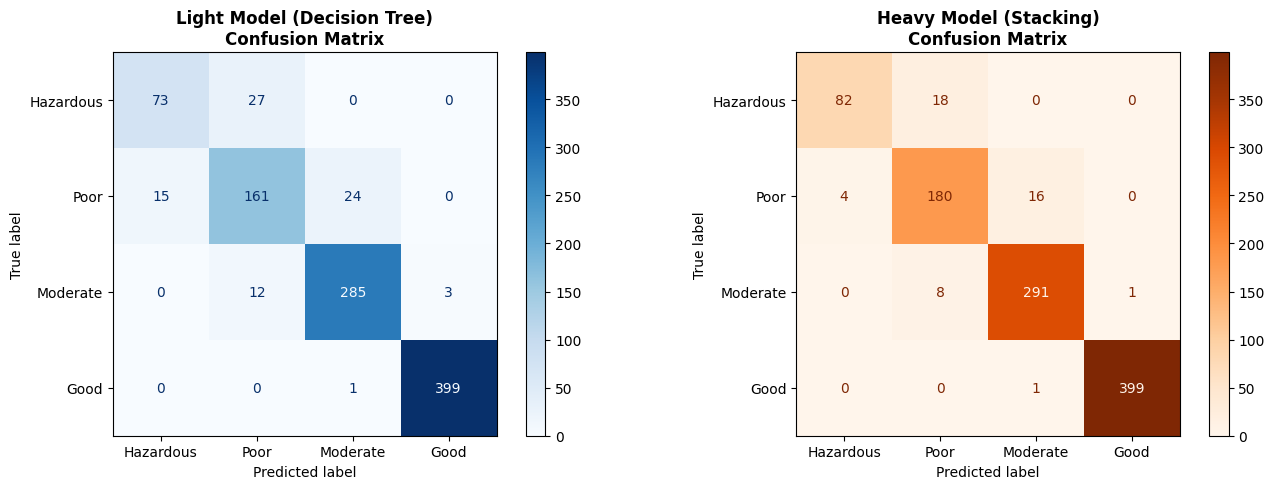

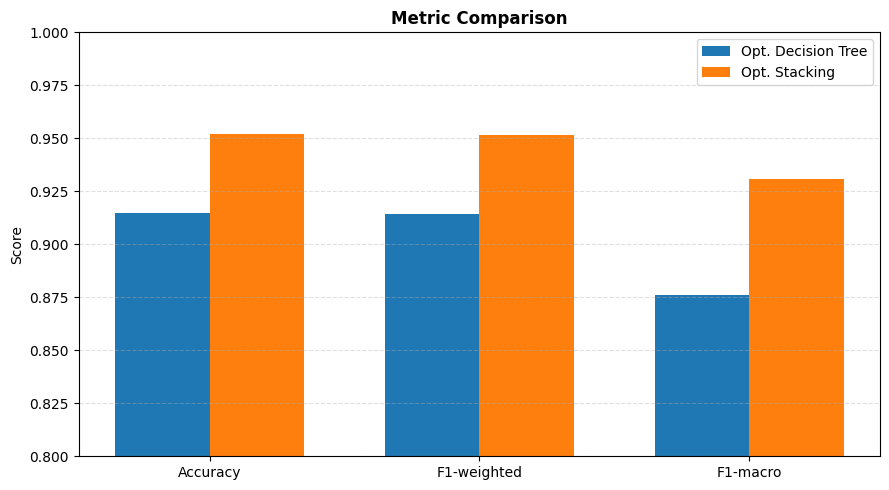

In [137]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on test set
light_pred_test = best_dt.predict(X_test)
heavy_pred_test = stacking_clf.predict(X_test)

cm_light = confusion_matrix(y_test, light_pred_test)
cm_heavy = confusion_matrix(y_test, heavy_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Light Model
disp_light = ConfusionMatrixDisplay(confusion_matrix=cm_light, display_labels=["Hazardous", "Poor", "Moderate", "Good"])
disp_light.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Light Model (Decision Tree)\nConfusion Matrix", fontsize=12, fontweight='bold')

# Heavy Model
disp_heavy = ConfusionMatrixDisplay(confusion_matrix=cm_heavy, display_labels=["Hazardous", "Poor", "Moderate", "Good"])
disp_heavy.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title("Heavy Model (Stacking)\nConfusion Matrix", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ["Accuracy", "F1-weighted", "F1-macro"]
x = np.arange(len(metrics))
w = 0.35

ax.bar(x - w/2, [accuracy_dt, f1_w_dt, f1_m_dt], width=w, label="Opt. Decision Tree")
ax.bar(x + w/2, [accuracy_stack, f1_w_stack, f1_m_stack], width=w, label="Opt. Stacking")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Score")
ax.set_title("Metric Comparison", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

Even if all classes are interesting to see, accuracy does not do justice to the minority class, as it takes very value equally good, F1 weighted equally treats every class and F1 macro gives special care to the monority class, that is where we mainly focus, as we are dealing with a recall critical problem.

The results suggest that even if both models did great, model stacking outsatnds, mainly in macro F1, which is the metric we give most importance to. Even if correctly classifying mayority classes is important too, just not as the hazardous one.

## Model Size Comparison
We will save the models to check the storage usage

In [63]:
import joblib

joblib.dump(best_dt, "../src/models/light_ensemble_model.pkl")
joblib.dump(stacking_clf, "../src/models/heavy_ensemble_model.pkl")

['../src/models/heavy_ensemble_model.pkl']

| Model | Weight |
| :--- | :--- |
| **Light DT model** | 17 kB |
| **Heavy Stack Model** | 13 MB |

## Inference Speed Comparison

In [68]:
print(X_test.head())

      Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
3237         35.7     102.1   39.7  49.8  19.5  13.0  2.04   
890          33.7      59.5   13.7  21.5  19.6   2.3  1.02   
1433         29.5      67.3    5.1  11.7  20.5   3.6  1.11   
3207         39.3      79.9    2.4  23.6  54.1  30.2  2.54   
3184         42.6      99.7   18.3  34.1  35.9  34.6  2.61   

      Proximity_to_Industrial_Areas  Population_Density  
3237                            7.2                 472  
890                            11.7                 511  
1433                           11.2                 379  
3207                            5.2                 733  
3184                            3.4                 832  


In [ ]:
test_sample_X = X_test.iloc[3]
test_sample_y = y_test.iloc[3]
print(f"Features of the 4th sample from the test set:\n{test_sample_X}")
print(f"\nTarget Class: {test_sample_y}, hazardous")

Features of the 4th sample from the test set:
Temperature                       39.30
Humidity                          79.90
PM2.5                              2.40
PM10                              23.60
NO2                               54.10
SO2                               30.20
CO                                 2.54
Proximity_to_Industrial_Areas      5.20
Population_Density               733.00
Name: 3207, dtype: float64

Target Class: 0, hazardous


In [ ]:
import time
input_data = test_sample_X.values.reshape(1, -1)

# light model inference
start_light = time.perf_counter()
light_pred = best_dt.predict(input_data)
end_light = time.perf_counter()
light_time = end_light - start_light

# heavy model inference
start_heavy = time.perf_counter()
heavy_pred = stacking_clf.predict(input_data)
end_heavy = time.perf_counter()
heavy_time = end_heavy - start_heavy

print(f"Inference Results")
print(f"Light Model Prediction: {light_pred[0]} (Time: {light_time:.4f}s)")
print(f"Heavy Model Prediction: {heavy_pred[0]} (Time: {heavy_time:.4f}s)")
print(f"Speed Difference: {heavy_time / light_time:.2f}x slower for Heavy Model")

Inference Results
Light Model Prediction: 1 (Time: 0.0003s)
Heavy Model Prediction: 0 (Time: 0.0374s)
Speed Difference: 129.22x slower for Heavy Model


## Conclusions

As we expected, the heavy model takes more to draw a conclusion comparing it to the decision tree, but the output is not correct, the sample used is not correctly classified by the smaller model, even if it only misses the grade of the air toxicity by 1. In a real world scenario, where the minority class is the most dangerous one, missclassifying it, even if only by one space difference, can cause enormous damages, even if the results are impresive given the size difference of 17kB against 13MB. Depending in the hardware, the smaller model could do the job, but if the job needed it, the heavy model would bring more accurate results, given we optimized the hyperparameters to take the minority class more into account (with the Macro F1 Score focused optuna).

### 2. Conformal Prediction

Instead of forcing the model to output a single prediction (e.g., "Poor"), conformal pre-
diction allows the model to output a set of predictions with a defined chance of containing
the true class (e.g., predicting {Moderate, Poor} with 0.95 confidence).
We will study ways of changing the size of the prediction set between an uncalibrated
Random Forest and a well-calibrated LightGBM and how it reacts when faced with noisy
sensor data

Therefore, we look into the drawbacks of modifying the loss function in order to heavily
penalize hazardous quality miss-classifications and understanding if ordinal costs outper-
form synthetic data generation.